In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

import pyswarms as ps
from deap import base, creator, tools, algorithms
import random

In [5]:
df = pd.read_csv("cleandata.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

series = df['demand_kWh']
series = series.asfreq('h')
series = series.ffill()

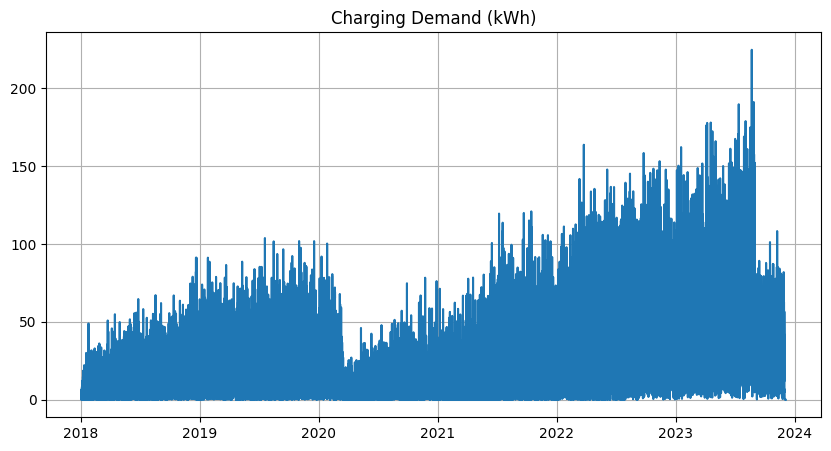

In [6]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Charging Demand (kWh)")
plt.grid()
plt.show()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [7]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(0,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

sarima_fit = sarima_model.fit(disp=False, low_memory=True)
sarima_pred = sarima_fit.forecast(steps=len(test))

In [8]:
# SCALING + SEQUENCES
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(scaled, window)

X_train, X_test = X[:train_size-window], X[train_size-window:]
y_train, y_test = y[:train_size-window], y[train_size-window:]

y_test_inv = scaler.inverse_transform(y_test)

In [9]:
# TCN MODEL
def build_tcn(filters=64, kernel_size=3, dropout=0.2):
    model = Sequential([
        TCN(filters, kernel_size=kernel_size, dropout_rate=dropout, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

tcn_model = build_tcn()
tcn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
tcn_pred = scaler.inverse_transform(tcn_model.predict(X_test))

2026-04-18 05:58:15,347 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Epoch 1/10



2026-04-18 05:58:16,279 - tensorflow - WARNING - From C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\backend\tensorflow\core.py:232: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.



1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - loss: 0.0082 - val_loss: 0.0047
Epoch 2/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0016 - val_loss: 0.0039
Epoch 3/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 4/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0015 - val_loss: 0.0038
Epoch 5/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 6/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0014 - val_loss: 0.0040
Epoch 7/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 8/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 9/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 10/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0014 - val_loss: 0.0039
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [10]:
# PSO OPTIMIZATION
def fitness_function(params):
    errors = []
    for p in params:
        model = build_tcn(int(p[0]), int(p[1]), float(p[2]))
        model.fit(X_train, y_train, epochs=5, verbose=0)

        pred = scaler.inverse_transform(model.predict(X_test))
        error = np.mean((pred - y_test_inv)**2)
        errors.append(error)
    return np.array(errors)

bounds = ([32, 2, 0.1], [128, 5, 0.5])

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1':0.5,'c2':0.3,'w':0.9},
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(fitness_function, iters=10)

pso_model = build_tcn(int(best_pos[0]), int(best_pos[1]), best_pos[2])
pso_model.fit(X_train, y_train, epochs=20, validation_split=0.2)
pso_pred = scaler.inverse_transform(pso_model.predict(X_test))


2026-04-18 06:01:48,131 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                |0/10

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


pyswarms.single.global_best:  10%|██████▌                                                          |1/10, best_cost=175

325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


pyswarms.single.global_best:  20%|█████████████                                                    |2/10, best_cost=175

...

325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


pyswarms.single.global_best:  90%|██████████████████████████████████████████████████████████▌      |9/10, best_cost=169

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


pyswarms.single.global_best: 100%|████████████████████████████████████████████████████████████████|10/10, best_cost=169
2026-04-18 08:52:57,589 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 168.83896562612526, best pos: [66.96192104  3.26876232  0.18375437]


Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - loss: 0.0084 - val_loss: 0.0040
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0016 - val_loss: 0.0043
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0014 - val_loss: 0.0039
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0014 - val_loss: 0.0039
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0014 - val_loss: 0.0040
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0014 - val_loss: 0.0047
Epoch 12

In [11]:
# GA OPTIMIZATION
def eval_individual(ind):
    model = build_tcn(int(ind[0]), int(ind[1]), ind[2])
    model.fit(X_train, y_train, epochs=5, verbose=0)

    pred = scaler.inverse_transform(model.predict(X_test))
    return (np.mean((pred - y_test_inv)**2),)

if "FitnessMin" not in creator.__dict__:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_filters", random.randint, 32, 128)
toolbox.register("attr_kernel", random.randint, 2, 5)
toolbox.register("attr_dropout", random.uniform, 0.1, 0.5)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_filters, toolbox.attr_kernel, toolbox.attr_dropout), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
pop, _ = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=True)

best_ind = tools.selBest(pop, 1)[0]

ga_model = build_tcn(int(best_ind[0]), int(best_ind[1]), best_ind[2])
ga_model.fit(X_train, y_train, epochs=20, validation_split=0.2)
ga_pred = scaler.inverse_transform(ga_model.predict(X_test))

TypeError: Attribute weights of <class 'deap.creator.FitnessMin'> must be a sequence.

In [ ]:
def metrics(actual, pred):
    actual = np.array(actual).flatten()
    pred = np.array(pred).flatten()
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    mape = np.mean(np.abs((actual - pred) / np.where(actual==0, 1e-8, actual))) * 100
    
    smape = np.mean(
        np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred)) / 2 + 1e-8)
    ) * 100
    
    r2 = r2_score(actual, pred)
    
    return mae, rmse, mape, smape, r2

In [ ]:
# EVALUATION
m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv, tcn_pred)
m_pso = metrics(y_test_inv, pso_pred)
m_ga = metrics(y_test_inv, ga_pred)

In [ ]:
results_df = pd.DataFrame({
    'Model': ['SARIMA', 'TCN', 'PSO-TCN', 'GA-TCN'],
    'MAE': [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]],
    'RMSE': [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]],
    'MAPE (%)': [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]],
    'SMAPE (%)': [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]],
    'R2': [m_sarima[4], m_tcn[4], m_pso[4], m_ga[4]],
})

print("\nMODEL PERFORMANCE COMPARISON:\n")
print(results_df)

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, sarima_pred.values, label='SARIMA')
plt.plot(test.index[-len(tcn_pred):], tcn_pred, label='TCN')
plt.plot(test.index[-len(pso_pred):], pso_pred, label='PSO-TCN')
plt.plot(test.index[-len(ga_pred):], ga_pred, label='GA-TCN')
plt.legend()
plt.title("Forecast vs Actual")
plt.grid()
plt.show()

In [ ]:
# Residuals
plt.figure(figsize=(14,6))
plt.plot(test.values - sarima_pred.values, label='SARIMA')
plt.plot(y_test_inv.flatten() - tcn_pred.flatten(), label='TCN')
plt.plot(y_test_inv.flatten() - pso_pred.flatten(), label='PSO-TCN')
plt.plot(y_test_inv.flatten() - ga_pred.flatten(), label='GA-TCN')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Residuals")
plt.show()

In [ ]:
# Metrics comparison
results_df.set_index('Model')[['MAE','RMSE','SMAPE (%)']].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison Metrics")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()